In [1]:
import pandas as pd
import torch

# --- Check GPU is available ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'  # use GPU if available
print(f"Using device: {device}")

# --- Load cleaned fraud dataset ---
df = pd.read_csv(r'C:\CareerShieldAI\datasets\fraud_cleaned.csv')  # load data

# --- Combine text columns into one ---
df['combined_text'] = df['description'] + ' ' + df['requirements']  # merge text
df['combined_text'] = df['combined_text'].fillna('')                 # fill empty

print(f"Total rows: {len(df)}")             # total job postings
print(f"Sample text:")
print(df['combined_text'][0][:200])         # preview first row

Using device: cuda
Total rows: 17880
Sample text:
Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and curated recipe hub, is currently interviewing full- and part-time unpaid interns to work in a small team o


In [2]:
from transformers import DistilBertTokenizer, DistilBertModel
import numpy as np

# --- Load pretrained DistilBERT model and tokenizer ---
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')  # load tokenizer
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased')     # load model
bert_model = bert_model.to(device)                                          # move to GPU
bert_model.eval()                                                            # set to evaluation mode

print("DistilBERT loaded on", device)

# --- Function to get embedding for one text ---
def get_embedding(text):
    # limit text to 512 characters to keep it fast
    text = str(text)[:512]

    # convert text to tokens (numbers DistilBERT understands)
    tokens = tokenizer(text,
                       return_tensors='pt',      # return pytorch tensors
                       truncation=True,          # cut if too long
                       max_length=128,           # max 128 tokens
                       padding='max_length')     # pad if too short

    # move tokens to GPU
    tokens = {k: v.to(device) for k, v in tokens.items()}

    # get embeddings from DistilBERT
    with torch.no_grad():                        # no gradient needed for inference
        output = bert_model(**tokens)            # pass tokens through model

    # take average of all token embeddings as final embedding
    embedding = output.last_hidden_state.mean(dim=1)  # average pooling
    return embedding.cpu().numpy()[0]            # return as numpy array

print("Embedding function ready.")
print("Testing on sample text...")

# --- Test on one example ---
sample = get_embedding("urgent hiring no experience needed")  # test embedding
print(f"Embedding shape: {sample.shape}")        # should be (768,)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\Vivek\.conda\envs\careershield\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Vivek\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT loaded on cuda
Embedding function ready.
Testing on sample text...
Embedding shape: (768,)


In [3]:
from tqdm import tqdm

# --- Generate embeddings for all job postings ---
embeddings = []                                      # empty list to store embeddings

# tqdm shows a progress bar so you can track progress
for text in tqdm(df['combined_text'], desc="Generating embeddings"):
    emb = get_embedding(text)                        # get embedding for each job
    embeddings.append(emb)                           # add to list

# --- Convert list to numpy array ---
embeddings = np.array(embeddings)                    # shape: (17880, 768)

print(f"Embeddings generated.")
print(f"Shape: {embeddings.shape}")                  # should be (17880, 768)

# --- Save embeddings to file (avoid regenerating every time) ---
np.save(r'C:\CareerShieldAI\ml_models\bert_embeddings.npy', embeddings)  # save
print("Embeddings saved to ml_models/bert_embeddings.npy")

Generating embeddings: 100%|██████████| 17880/17880 [01:46<00:00, 167.82it/s]


Embeddings generated.
Shape: (17880, 768)
Embeddings saved to ml_models/bert_embeddings.npy


In [6]:
import sys
sys.path.append(r'C:\CareerShieldAI\backend\app')

import pickle
import numpy as np
from scipy.sparse import hstack, csr_matrix
from preprocessing import add_fraud_features

# --- Load and preprocess fraud dataset ---
df = add_fraud_features(df)

# --- Load saved TF-IDF vectorizer ---
with open(r'C:\CareerShieldAI\ml_models\tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

# --- Convert text to TF-IDF features ---
text_features = tfidf.transform(df['combined_text'])

# --- Load saved BERT embeddings ---
embeddings = np.load(r'C:\CareerShieldAI\ml_models\bert_embeddings.npy')

# --- Get metadata features ---
meta = df[['suspicious_salary',
           'missing_profile',
           'scam_keywords',
           'telecommuting',
           'has_company_logo']].values

# --- Use only BERT + metadata (skip TF-IDF to save memory) ---
X = np.hstack([embeddings, meta])                    # combine bert + metadata only
y = df['fraudulent'].values                          # target variable

print("Features combined.")
print(f"Total features: {X.shape[1]}")               # should be 773
print(f"Total samples:  {X.shape[0]}")               # should be 17880

Features combined.
Total features: 773
Total samples:  17880


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# --- Fix class imbalance ---
smote = SMOTE(random_state=42)                       # balance real vs fake
X_balanced, y_balanced = smote.fit_resample(X, y)   # create balanced dataset

print("Class balance fixed.")
print(f"Real: {(y_balanced==0).sum()}, Fake: {(y_balanced==1).sum()}")

# --- Split into train and test ---
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,                                   # 20% for testing
    random_state=42)                                 # reproducible split

# --- Train model ---
model_bert = LogisticRegression(max_iter=1000)       # logistic regression model
model_bert.fit(X_train, y_train)                     # train on balanced data

print("Model trained successfully.")
print(f"Training samples: {X_train.shape[0]}")       # training rows
print(f"Testing samples:  {X_test.shape[0]}")        # testing rows

Class balance fixed.
Real: 17014, Fake: 17014
Model trained successfully.
Training samples: 27222
Testing samples:  6806


Improved Model Evaluation (BERT + Metadata):
              precision    recall  f1-score   support

        Real       0.96      0.90      0.93      3396
        Fake       0.91      0.96      0.93      3410

    accuracy                           0.93      6806
   macro avg       0.93      0.93      0.93      6806
weighted avg       0.93      0.93      0.93      6806

Confusion Matrix:
[[3057  339]
 [ 144 3266]]

Model Comparison:
Day 3 (TF-IDF only)    → Accuracy: 93%
Day 4 (BERT + Metadata) → Accuracy: 92.9%


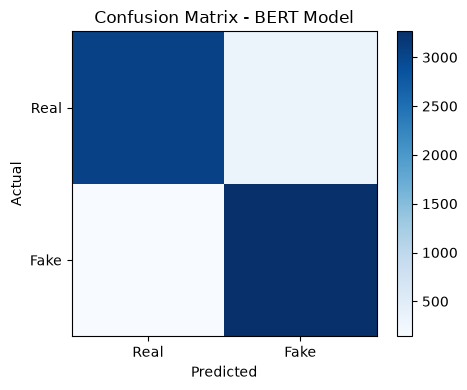

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- Make predictions on test data ---
y_pred = model_bert.predict(X_test)                  # predict real or fake

# --- Print evaluation metrics ---
print("Improved Model Evaluation (BERT + Metadata):")
print(classification_report(y_test, y_pred,
      target_names=['Real', 'Fake']))                # precision, recall, f1

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)                # actual vs predicted
print("Confusion Matrix:")
print(cm)

# --- Compare with Day 3 model ---
print("\nModel Comparison:")
print(f"Day 3 (TF-IDF only)    → Accuracy: 93%")    # previous model
print(f"Day 4 (BERT + Metadata) → Accuracy: {round((y_pred == y_test).mean()*100, 2)}%")  # new model

# --- Plot confusion matrix ---
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - BERT Model')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0,1], ['Real','Fake'])
plt.yticks([0,1], ['Real','Fake'])
plt.tight_layout()
plt.show()

In [10]:
import pickle

# --- Save improved BERT model ---
with open(r'C:\CareerShieldAI\ml_models\fraud_model_bert.pkl', 'wb') as f:
    pickle.dump(model_bert, f)                       # save model to file

print("Improved model saved to ml_models/fraud_model_bert.pkl")
print("\nFinal model files:")
print("fraud_model.pkl      → Day 3 baseline (TF-IDF)")
print("fraud_model_bert.pkl → Day 4 improved (BERT + Metadata)")
print("bert_embeddings.npy  → saved embeddings (no need to regenerate)")
print("tfidf_vectorizer.pkl → saved TF-IDF vectorizer")

Improved model saved to ml_models/fraud_model_bert.pkl

Final model files:
fraud_model.pkl      → Day 3 baseline (TF-IDF)
fraud_model_bert.pkl → Day 4 improved (BERT + Metadata)
bert_embeddings.npy  → saved embeddings (no need to regenerate)
tfidf_vectorizer.pkl → saved TF-IDF vectorizer
